In [2]:
from IPython.display import display, HTML
import os
import pickle
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate
) 
from sklearn.base import clone
from sklearn.metrics import (
    get_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

from openai import OpenAI

from wordcloud import WordCloud, STOPWORDS
from PIL import Image

from utils import (
    basic_data_clean,
    TextProcessing,
    get_timestamp
)

from llm_inference import (
    llm_classify,
    llm_batch_records
)

# File locations
dirpath_data = 'datasets/'
fpath_fake_data = dirpath_data + 'Fake.csv'
fpath_real_data = dirpath_data + 'True.csv'
dirpath_models = 'models/'
dirpath_results = 'results/'

llm_batch_size = 50

# RNG setup
random_state = 13
np.random.seed(random_state)
rng = np.random.default_rng()

# Loading spacy model and cleaner
spacy_model = spacy.load('en_core_web_sm')

# Data Cleaning and Exploratary Data Analysis

In [3]:
# Basic dataset description and cleaning
news_data_fake = pd.read_csv(fpath_fake_data)
news_data_real = pd.read_csv(fpath_real_data)

def describe_df(df, data_title: str):
    print(f'{data_title} ---- ')
    print(f' > shape: {df.shape}')
    print(f' > duplicated records: {df.duplicated().sum()}')
    print(f' > empty records: {df.isnull().all(axis=1).sum()}')
   
    return pd.DataFrame({
        'Example' : df.iloc[0],
        'Data Type' : df.dtypes,
        'NaN Values' : df.isnull().sum(),
        'NaN %' : np.round(df.isnull().mean()*100, 0),
        'Unique Records' : df.nunique(),
        'Duplicated Records' : df.shape[0] - df.nunique()
    })

display(describe_df(news_data_fake, 'Fake News Data'))
print()
display(describe_df(news_data_real, 'Real News Data'))

Fake News Data ---- 
 > shape: (7787, 4)
 > duplicated records: 3730
 > empty records: 3731


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,Donald Trump Sends Out Embarrassing New Year’...,str,3731,48.0,4055,3732
text,Donald Trump just couldn t wish all Americans ...,str,3731,48.0,4056,3731
subject,News,str,3731,48.0,1,7786
date,"December 31, 2017",str,3731,48.0,425,7362



Real News Data ---- 
 > shape: (21417, 4)
 > duplicated records: 206
 > empty records: 0


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,"As U.S. budget fight looms, Republicans flip t...",str,0,0.0,20826,591
text,WASHINGTON (Reuters) - The head of a conservat...,str,0,0.0,21192,225
subject,politicsNews,str,0,0.0,2,21415
date,"December 31, 2017",str,0,0.0,716,20701


In [4]:
# Basic data cleaning - removing empty records and duplicated records
news_data_fake_cleaned = basic_data_clean(news_data_fake)
news_data_real_cleaned = basic_data_clean(news_data_real)

display(describe_df(news_data_fake_cleaned, 'Fake News (cleaned)'))
display(describe_df(news_data_real_cleaned, 'Real News (cleaned)'))

Fake News (cleaned) ---- 
 > shape: (4056, 4)
 > duplicated records: 0
 > empty records: 0


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,Donald Trump Sends Out Embarrassing New Year’...,str,0,0.0,4055,1
text,Donald Trump just couldn t wish all Americans ...,str,0,0.0,4056,0
subject,News,str,0,0.0,1,4055
date,"December 31, 2017",str,0,0.0,425,3631


Real News (cleaned) ---- 
 > shape: (21196, 4)
 > duplicated records: 0
 > empty records: 0


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,"As U.S. budget fight looms, Republicans flip t...",str,0,0.0,20825,371
text,WASHINGTON (Reuters) - The head of a conservat...,str,0,0.0,21191,5
subject,politicsNews,str,0,0.0,2,21194
date,"December 31, 2017",str,0,0.0,716,20480


In [5]:
# Both datasets seem to share the same features - okay to join
# Selecting Fake News = 1 (target feature) and Real News = 0
news_data_fake_cleaned['target'] = 1
news_data_real_cleaned['target'] = 0

news_data_joined = pd.concat([news_data_fake_cleaned, news_data_real_cleaned])
display(describe_df(news_data_joined, 'Joined Data'))
news_data_joined.drop(columns='target').to_csv(dirpath_data + 'joined_data.csv')

Joined Data ---- 
 > shape: (25252, 5)
 > duplicated records: 0
 > empty records: 0


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,Donald Trump Sends Out Embarrassing New Year’...,str,0,0.0,24880,372
text,Donald Trump just couldn t wish all Americans ...,str,0,0.0,25247,5
subject,News,str,0,0.0,3,25249
date,"December 31, 2017",str,0,0.0,1141,24111
target,1,int64,0,0.0,2,25250


In [6]:
# Train-Test Split
# Total dataset is ~25K rows - not an overwhelming abundance of training data
# Suggest using 80-20 train-test split, with validation using Cross Validation
# Stratified, as proportion of fake news is low and we want to ensure training
#   is conducted with some samples of fake news
# Keeping target with data to handle potential row duplication during EDA

df_train, df_test, _, __ = train_test_split(
    news_data_joined,
    news_data_joined['target'],
    train_size = 0.8,  # 80% train proportion due to limited data size
    shuffle=True,
    stratify=news_data_joined['target'],
)

print(f'Training data: {df_train.shape}')
print(f'Test data: {df_test.shape}')

Training data: (20201, 5)
Test data: (5051, 5)


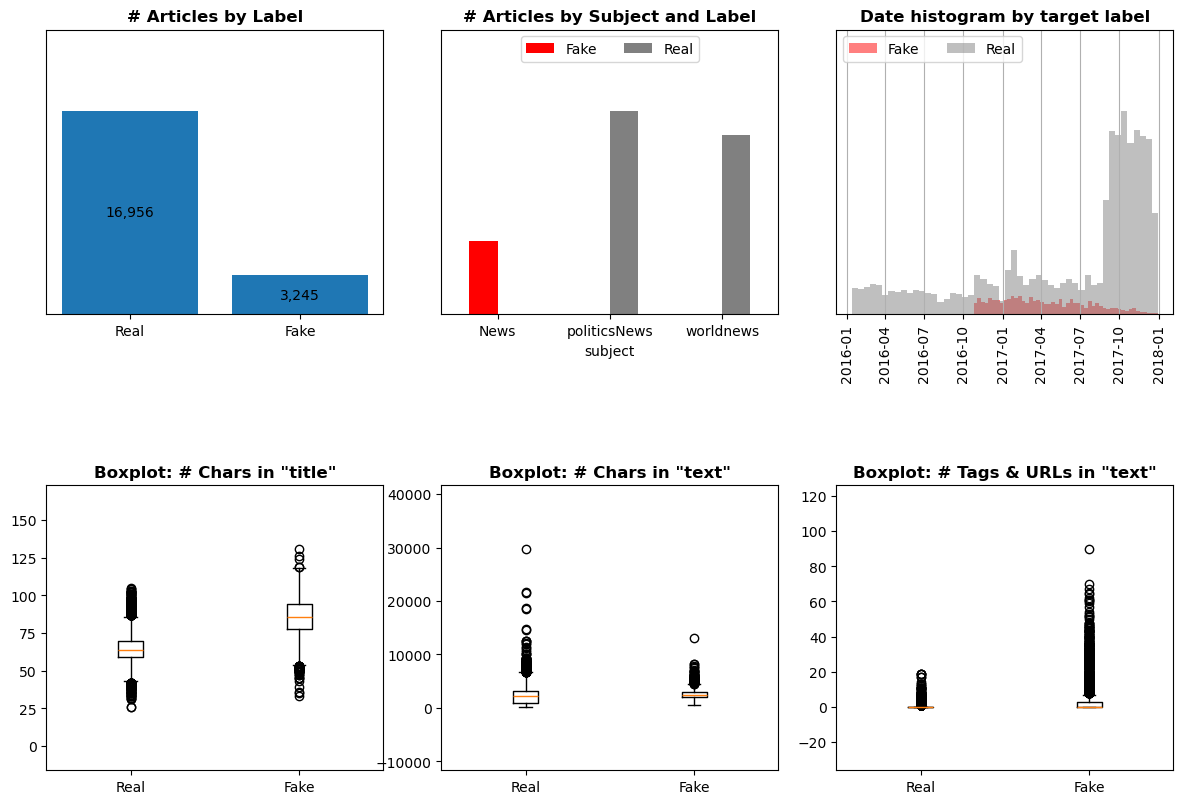

In [7]:
# EDA
fig, axs = plt.subplots(2,3, 
                        figsize=(12, 8))
fig.tight_layout()
fig.subplots_adjust(hspace=0.6)

df_eda = df_train.copy()
df_eda['target_label'] = df_train['target'].replace({0:'Real', 1:'Fake'})

target_labels = ['Real', 'Fake']
real_news_mask = df_eda['target']==0
fake_news_mask = df_eda['target']==1
masks = (real_news_mask, fake_news_mask)

target_colour = {
    'Real' : 'grey',
    'Fake' : 'red'
}

def format_subplot(ax, title: str, show_y=False):
    ax.set_title(title, fontweight='bold')
    ax.get_yaxis().set_visible(show_y)
    ax.margins(y=0.4)
    return None

# Class (im)-balance
ax1 = axs[0][0]
format_subplot(ax1, '# Articles by Label', show_y=False)

counts = df_eda['target'].value_counts().sort_index()
class_imbalance = ax1.bar(
    target_labels,
    counts
)
ax1.bar_label(
    class_imbalance,
    labels=['{:,}'.format(count)
        for count in counts],
    label_type = 'center'
)

# Distribution of subject vs target
ax2 = axs[0][1]
subject_counts = (df_eda
                  .groupby(['subject', 'target_label'])
                  .size()
                  .unstack())
subject_counts.plot(kind='bar', ax=ax2, color=target_colour)

format_subplot(ax2, '# Articles by Subject and Label', show_y=False)
ax2.legend(loc='upper center', ncols=len(target_labels))
ax2.tick_params(axis='x', labelrotation=0)

# Distribution of dates by target label
ax3 = axs[0][2]

date_group = df_eda.groupby('target_label')['date']
for (label, series) in date_group:
    dates = pd.to_datetime(series)
    dates.hist(
        bins=50,
        label=label,
        alpha=0.5,
        color=target_colour[label],
        ax=ax3
    )

format_subplot(ax3, 'Date histogram by target label', show_y=False)
ax3.tick_params(axis='x', labelrotation=90)
ax3.legend(loc='upper left', ncols=len(target_labels))

# Distribution of title and text length by target label
for [ax,col] in [
    [axs[1][0],'title'],
    [axs[1][1],'text']
]:
    ax.boxplot(
        [
            df_eda[real_news_mask][col].str.len(),
            df_eda[fake_news_mask][col].str.len(),
        ],
        tick_labels = target_labels
    )
    format_subplot(ax, 'Boxplot: # Chars in "' + col + '"', show_y=True)

# Distribution of Tags and URLs
ax4 = axs[1][2]

re_pattern = r'@\w+|#\w+'
re_pattern += r'|https?://\S+|www\.\S+'

format_subplot(ax4, 'Boxplot: # Tags & URLs in "text"', show_y=True)
ax4.boxplot([
                df_eda[masks[i]]['text'].str.count(re_pattern)
                for i in np.arange(len(masks))
            ],
           tick_labels=target_labels)

plt.savefig(dirpath_results + 'eda_plots.jpg')
plt.show()

### EDA Observations
The dataset is imbalanced, with over 5x more Real articles than Fake articles; the train-test split will need to be stratified to ensure that both train and test splits contains sufficient samples of the target and classifier performance should be measured according to the arithmetic / macro mean so that the performance on identifying Real articles does not outweigh the Fake articles.

The "# Articles by Subject and Label" visualisation reveals that the subject of the articles is 1:1 correlated with the target label and therefore must be removed from our dataset to prevent leakage. Date, however, is less obviously correlated ("Date histogram by target label"), though this analysis will ignore Date in the first instance as it is less obvious from the visualization and from subject matter knowledge how dates may correlate with the prevalence of Fake news - this feature could be added back in if the other features are not sufficient.

The length of the titles indicates that Fakes news articles appear to be more verbose, though the inverse of this is true for the content of the article itself ("text"). Finally, the number of # or @-tags and URLs in Fake news articles seems to have a longer 'tail' (i.e. outliers) than for Real news articles, where its distribution is more concentrated around its median. Both of these factors indicate that article length and the number of tags / URLs in the article could be useful features for modelling.

In [7]:
# Separating target from training and test datasets
X_train = df_train.drop(columns='target')
y_train = df_train['target']
X_test = df_test.drop(columns='target')
y_test = df_test['target']

y_train = y_train
y_test = y_test

In [8]:
# Data Pre-processing
# Providing examples of what the data looks like post-processing
text_processor = TextProcessing(lemma=True, batch_size=100)
display(describe_df(text_processor.transform(X_train[:100]), "Example: Pre-Processed Joined Data"))

Lemmatizing...
Lemma complete
Example: Pre-Processed Joined Data ---- 
 > shape: (100, 6)
 > duplicated records: 0
 > empty records: 0


,Example,Data Type,NaN Values,NaN %,Unique Records,Duplicated Records
title,Palestinian gunman kills three Israeli guards ...,string,0,0.0,100,0
text,"HAR ADAR, West Bank (Reuters) - A Palestinian ...",string,0,0.0,100,0
date,2017-09-26 00:00:00,datetime64[ns],0,0.0,89,11
tag_url_count,0,Int64,0,0.0,5,95
normalized_title,palestinian gunman kill israeli guard west ban...,str,0,0.0,100,0
normalized_text,har adar west bank reuters palestinian man sec...,str,0,0.0,100,0


In [9]:
# Model Pipeline
data_transformer = ColumnTransformer(
    transformers = [
        ('tfidf_title', TfidfVectorizer(), 'normalized_title'),
        ('tfidf_text', TfidfVectorizer(), 'normalized_text'),
        ('tag_url_count', StandardScaler(), ['tag_url_count']),
    ],
    remainder='drop'
)

lr_train_pipeline = Pipeline(
    [
        ('transform_data', data_transformer),
        ('logisticregression', LogisticRegression(class_weight='balanced'))
    ]
)

# Cross-validation
inner_cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = random_state
)

outer_cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = random_state
)

param_grid = [
    {'logisticregression__C' : [0.001, 0.01, 0.1, 1, 10, 100, 1000],
     'logisticregression__solver' : ['lbfgs', 'liblinear'],
    }
]

In [10]:
# Pre-processing X_train for Logistic Regression
X_train_preprocessed = text_processor.transform(X_train)
X_test_preprocessed = text_processor.transform(X_test)

Lemmatizing...
Lemma complete
Lemmatizing...
Lemma complete


In [11]:
X_train_preprocessed.shape

(20201, 6)

In [12]:
y_train.shape

(20201,)

In [13]:
print(set(X_train_preprocessed.index).difference(set(y_train.index)))

set()


In [14]:
# GridSearch CV to find parameters
gridsearch_lr = GridSearchCV(
    estimator = lr_train_pipeline,
    param_grid = param_grid,
    scoring = 'f1_macro',
    cv = inner_cv
)

gridsearch_lr.fit(X_train_preprocessed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__solver': ['lbfgs', 'liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

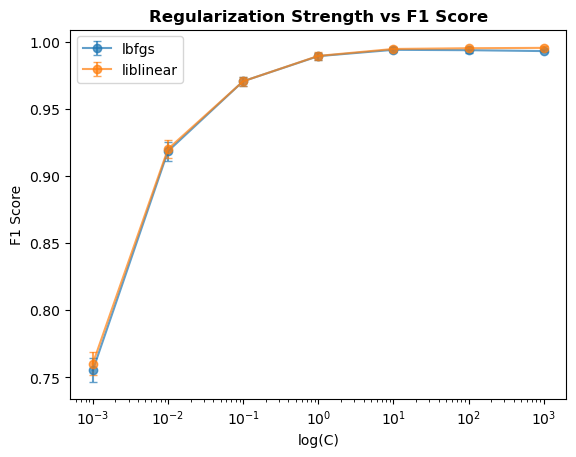

In [15]:
# Determining performance and threshold for overfitting
lr_model = gridsearch_lr.best_estimator_
df_results = pd.DataFrame(gridsearch_lr.cv_results_)

for solver, group in df_results.groupby('param_logisticregression__solver'):
    group = group.sort_values('param_logisticregression__C')
    plt.errorbar(
        group['param_logisticregression__C'],
        group['mean_test_score'],
        yerr = group['std_test_score'],
        marker = 'o',
        capsize = 3,
        label = solver,
        alpha = 0.7
    )

plt.xscale('log')
plt.xlabel('log(C)')
plt.ylabel('F1 Score')
plt.title('Regularization Strength vs F1 Score', fontweight='bold')
plt.legend(loc='upper left')

plt.savefig(dirpath_results + 'lr_regularization_vs_f1.jpg')
plt.show()

In [16]:
# Choosing 'liblinear' and C = 10 as that seems to be the inflection
#   point for training loss plateau, indicating start of overfitting
lr_model = clone(gridsearch_lr.estimator)
lr_model.set_params(
    logisticregression__C = 1,
    logisticregression__solver = 'liblinear'
)
lr_model.fit(X_train_preprocessed, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform_data', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_title', ...), ('tfidf_text', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [17]:
scores = [
    'precision',
    'recall',
    'f1',
    'accuracy'
]

cv_scores = cross_validate(
    lr_model,
    X_train_preprocessed,
    y_train,
    cv = outer_cv,
    scoring = scores,
    return_train_score=True
)
display(pd.DataFrame(cv_scores).round(3))
# Model seems not to vary wildly between train and test
#  indicating good generalization performance

,fit_time,score_time,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_accuracy,train_accuracy
0,1.789,0.420,0.970,0.989,0.980,1.0,0.975,0.994,0.992,0.998
1,1.751,0.396,0.967,0.988,0.995,1.0,0.981,0.994,0.994,0.998
2,1.756,0.420,0.985,0.989,0.985,1.0,0.985,0.994,0.995,0.998
3,1.758,0.407,0.982,0.990,0.985,1.0,0.983,0.995,0.995,0.998
4,1.761,0.407,0.988,0.990,0.989,1.0,0.988,0.995,0.996,0.998


In [18]:
# Classifier Performance Metrics
def classifier_scores(y_test, y_pred, labels):
    scores = {}
    scores['accuracy'] = accuracy_score(y_test, y_pred)
    scores['precision'], scores['recall'], scores['f1'], _ = precision_recall_fscore_support(
        y_test, y_pred
    )
    cm = ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels = labels
    )
    return scores, cm

In [19]:
lr_y_pred = lr_model.predict(X_test_preprocessed)
lr_scores, lr_cm = classifier_scores(y_test, lr_y_pred, ['Real', 'Fake'])

In [20]:
# Saving model
model_fname = 'lr_model.pkl'
pickle.dump(lr_model, open(dirpath_models + model_fname, 'wb'))

# Saving results
df_lr_results = pd.concat(
    [
        X_test_preprocessed,
        y_test,
        pd.Series(
            lr_y_pred,
            index=X_test_preprocessed.index,
            name='y_pred'
        )
    ],
    axis=1
)

df_lr_results.to_csv(dirpath_results + f'lr_{get_timestamp()}.csv')

In [21]:
# GenAI-based approach: Zero-shot prompting
# Note: Using a subset of the test set to reduce API cost
llm_model = 'gpt-5.4-mini'
df_llm_test = df_test[:1500]
batches = llm_batch_records(
    df_llm_test.drop(columns='target'),
    batch_size=llm_batch_size
)

start_time = time.perf_counter()
llm_classifications, token_usage = llm_classify(batches, llm_model)
llm_time = time.perf_counter() - start_time

Classifying Batch: 1 | 50 articles
Classifying Batch: 2 | 50 articles
Classifying Batch: 3 | 50 articles
Classifying Batch: 4 | 50 articles
Classifying Batch: 5 | 50 articles
Classifying Batch: 6 | 50 articles
Classifying Batch: 7 | 50 articles
Classifying Batch: 8 | 50 articles
Classifying Batch: 9 | 50 articles
Classifying Batch: 10 | 50 articles
Classifying Batch: 11 | 50 articles
Classifying Batch: 12 | 50 articles
Classifying Batch: 13 | 50 articles
Classifying Batch: 14 | 50 articles
Classifying Batch: 15 | 50 articles
Classifying Batch: 16 | 50 articles
Classifying Batch: 17 | 50 articles
Classifying Batch: 18 | 50 articles
Classifying Batch: 19 | 50 articles
Classifying Batch: 20 | 50 articles
Classifying Batch: 21 | 50 articles
 >> API Token Rate Limit hit on attempt # 1. Sleeping for 2s
Classifying Batch: 22 | 50 articles
Classifying Batch: 23 | 50 articles
 >> API Token Rate Limit hit on attempt # 1. Sleeping for 2s
Classifying Batch: 24 | 50 articles
 >> API Token Rate Limi

In [22]:
# Classifier performance metrics
llm_classifications = llm_classifications.join(df_llm_test['target'])

y_test = llm_classifications['target']
llm_y_pred = llm_classifications['llm_y_pred']
llm_scores, llm_cm = classifier_scores(y_test, llm_y_pred, ['Real', 'Fake'])

In [29]:
# Saving results
llm_classifications.to_csv(dirpath_results + f'llm_{get_timestamp()}.csv')

lr                      llm                  
               0      1 Macro Mean      0      1 Macro Mean
accuracy   0.997  0.997      0.997  0.979  0.979      0.979
precision  0.998  0.988      0.993  0.987  0.936      0.962
recall     0.998  0.991      0.995  0.987  0.936      0.962
f1         0.998  0.990      0.994  0.987  0.936      0.962

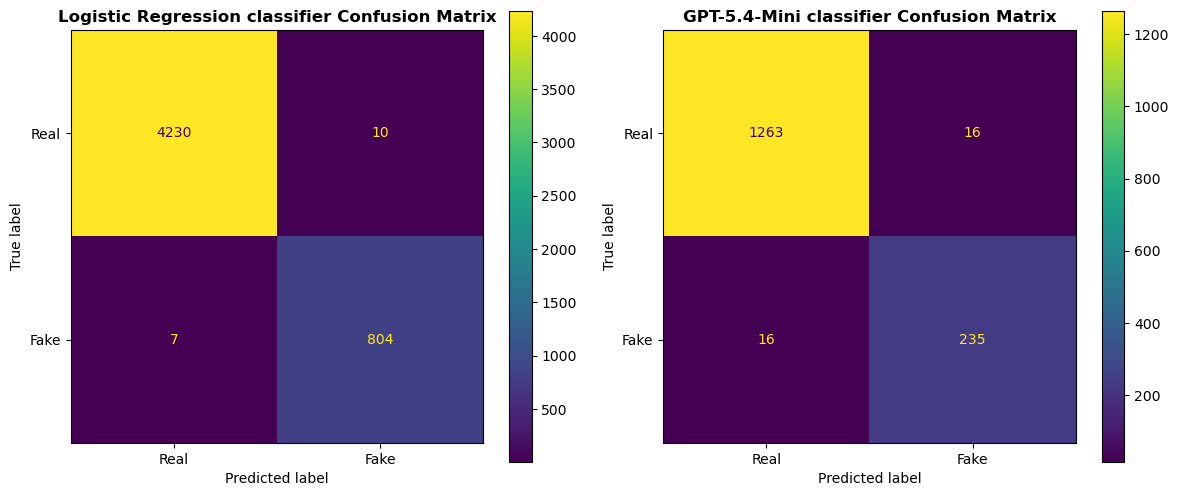

In [40]:
# Printing and saving scores
def score_to_df(scores):
    df = pd.DataFrame(scores).T
    df['Macro Mean'] = df.mean(axis=1)
    return df

df_scores = pd.concat(
    {
        "lr" : score_to_df(lr_scores),
        "llm" : score_to_df(llm_scores)
    },
    axis=1
)

display(df_scores.round(3))
df_scores.to_csv(
    dirpath_results + 'classifier_scores.csv',
    
)

# Plotting Confusion Matrices
fig, axs = plt.subplots(1,2, figsize=(12, 5))
for i, ax in enumerate(axs):
    cm = [lr_cm, llm_cm][i]
    cm.plot(ax=ax)
    ax.set_title(
        f'{["Logistic Regression", "GPT-5.4-Mini"][i]} classifier Confusion Matrix',
        fontweight='bold'
    )
    
plt.tight_layout()
plt.savefig(dirpath_results + 'confusion_matrices.jpg')
plt.show()

### Classifier performance comparison
We see that the Logistic Regression model performed better than the zero-shot LLM-based approach, notably with the Logistic Regression model producing fewer False Positives and False Negatives despite handling a larger number of test records; this is reflected in the stronger scores across all displayed metrics for the positive class ('1' = 'Fake news').

The Logistic Regression model also seems to display a bias towards classifying articles as Real, with stronger scores for the negative class ('0' = 'Real news') as well as fewer False Positives being identified despite there being a class imbalance in favour of Real articles. This implies that the model is slightly more likely to distrust news articles, potentially leading users to ignore the 'truth' more often than to accept Fake news.

## Latency and Costs

In [31]:
# Running multiple predictions for run times
n_loops = 100
lr_times = []
for i in range(n_loops):
    start_time = time.perf_counter()
    lr_model.predict(X_test_preprocessed)
    end_time = time.perf_counter()
    lr_times.append(end_time - start_time)

lr_times = np.array(lr_times)

In [32]:
# Latency
def print_inference_times(
    model_name,
    n_records,
    mean_time,
    std_time=None
):
    print(f'''
{model_name} inference time
--------------------
# Articles: \t{"{:,}".format(n_records)}
Mean Time: \t{mean_time:.3}s
Mean/Article: \t{mean_time/n_records * 1000:.3f} ms
{f"Std Time: {std_time:.3f}s" if std_time is not None else ""}
    ''')
    return None


print_inference_times(
    'Logistic Regression',
    X_test_preprocessed.shape[0],
    lr_times.mean(),
    lr_times.std()
)

print_inference_times(
    llm_model,
    df_llm_test.shape[0],
    llm_time
)


Logistic Regression inference time
--------------------
# Articles: 	5,051
Mean Time: 	0.439s
Mean/Article: 	0.087 ms
Std Time: 0.015s
    

gpt-5.4-mini inference time
--------------------
# Articles: 	1,500
Mean Time: 	1.81e+02s
Mean/Article: 	120.480 ms

    


In [33]:
# Costs: https://developers.openai.com/api/docs/models/gpt-5.4-mini
llm_costs = {
    'input' : 0.75 / 1000000,
    'output' : 4.5 / 1000000,
}

llm_cost = 0
llm_cost = llm_costs['input']*token_usage['input'] + \
            llm_costs['output']*token_usage['output']

print(f'''Total Cost: ${llm_cost:,.2f}
--------------------------------------
Input Tokens: \t\t{token_usage['input']:,}
Output Tokens: \t\t{token_usage['output']:,}
Number of articles: \t{df_llm_test.shape[0]:,}
Avg. cost/article: \t{llm_cost/df_llm_test.shape[0]*100:,.4f} cents
''')

Total Cost: $0.65
--------------------------------------
Input Tokens: 		770,511
Output Tokens: 		16,691
Number of articles: 	1,500
Avg. cost/article: 	0.0435 cents



### Latency
The Logistic Regression model, once trained, is materially faster at inference, averaging over 1,000x faster than the LLM-only (GPT-5.4-mini) approach.
Additionally, the commercially hosted LLM has token rate usage limits (currently at 200K tokens per minute) - this introduces artificial limits on inference times and make comparison against the Logistic Regression model unfavourable. 

*Note: LLM inference time is based on a single pass through a reduced test dataset to limit costs*

### Costs
As the LLM is driven by API calls to a commercial model (GPT-5.4-mini), it has associated costs - average ~0.04c per article whilst the Logistic Regression model has no associated cost.

Costs for the LLM-based model could be further reduced in several ways:
 - Using a more cost-effective API call ('batch' or 'flex') at the cost of increased latency
 - Using a smaller or cheaper commercial model
 - Self-hosted LLM (though this may incur other costs such as acquiring hardware to reduce latency)
 - Tweaking the prompts to use fewer tokens, though output tokens (the most expensive type) is already quite minimal

## Robustness Checks

In [34]:
# Partial Text - using just the title and ~60% of article
partial_percentage = 0.4
df_test_partial = df_test.copy()
df_test_partial['text'] = df_test_partial['text'].apply(
    lambda x: ' '.join(
        x.split()[:int(len(x.split())*partial_percentage)]
    )
)

X_test_partial = text_processor.transform(df_test_partial.drop(columns='target'))
y_test = df_test_partial['target']

Lemmatizing...
Lemma complete


lr                  lr-partial                 
             0     1 Macro Mean          0     1 Macro Mean
accuracy   1.0  1.00       1.00       0.98  0.98       0.98
precision  1.0  0.99       0.99       0.98  1.00       0.99
recall     1.0  0.99       0.99       1.00  0.89       0.95
f1         1.0  0.99       0.99       0.99  0.94       0.97

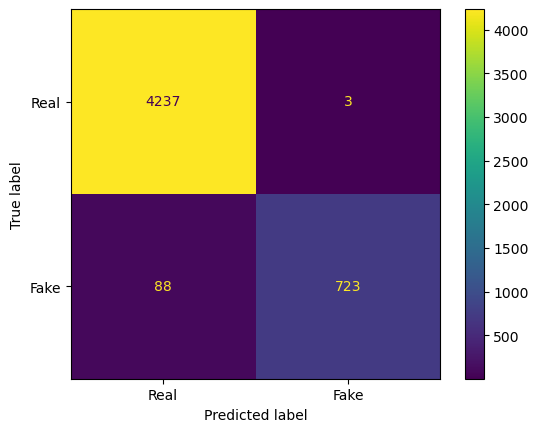

In [35]:
lr_partial_y_pred = lr_model.predict(X_test_partial)
lr_partial_scores, lr_partial_cm = classifier_scores(
    y_test,
    lr_partial_y_pred,
    ['Real', 'Fake']
)

df_lr_scores = pd.concat(
    {
        'lr' : score_to_df(lr_scores),
        'lr-partial' : score_to_df(lr_partial_scores)
    },
    axis=1
)

df_lr_scores.to_csv(dirpath_results + 
                    f'lr_{partial_percentage}pct_{get_timestamp()}.csv')

display(df_lr_scores.round(2))
lr_partial_cm.plot()
plt.show()

### Impact of partial text availability on classifier performance
At 40% of text available to the classifer, we see a slight reduction in precision and a significant reduciton in recall for the Fake news articles (positive class), with the classifier providing much higher false negatives. This would mean that the logistic regression classifier is now more likely to mistakenly tell users that Fake news articles are Real, and would be more likely to spread misinformation; interestingly, the model is less likely to classify a Real article as Fake news, which is the inverse of the findings earlier. This could imply that article length is correlated with Real/Fake News (in line with earlier EDA observations) or that key words in Fake news articles are more likely to appear further in the article itself.

### Enhancements to Robustness
It would be interesting in future work to see what the minimum text percentage would need to be in order for the classifier to no longer be effective, which could be achieved by running the model over different amounts of text availability and mapping that against its performance metrics. Additionally, the 'reluctance' of the model to misclassify Real articles as Fake indicates that tweaking class weights and classification thresholds could help to balance out the misclassifications, assuming that is a desired outcome.

Another hypothesis to be tested would be the impact of text availability on the LLM-based approach. LLMs may be more resilient to a reduction in text availability given its implied knowledge about news and current affairs imparted during model training.

Finally, a hybrid approach to handling data robustness is the use of LLMs to "fill in the blanks" with synthetic data, with future work to measure how synthetic data impacts the performance of both classification approaches.

# Insights and Limitations
Key Learnings
Typical failure cases and what they suggest
Concrete improvement ideas
GenAI: privacy / cost / compute

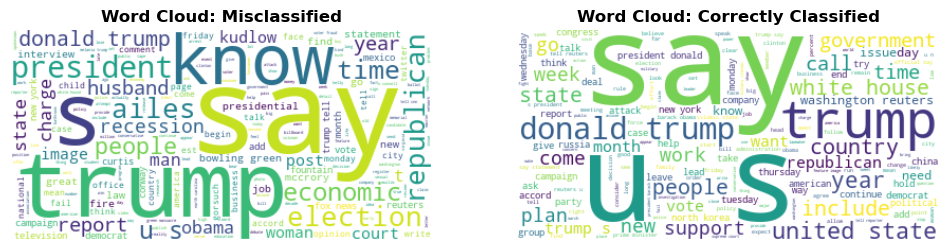

In [37]:
# Word Cloud of misclassified articles
stopwords = set(STOPWORDS)
def generate_word_cloud(text, stopwords):
    wordcloud_text = " ".join(
        article for article in 
        text
    )   
    wordcloud = WordCloud(
        stopwords=stopwords,
        background_color='white'
    ).generate(wordcloud_text)
    
    return wordcloud

misclassified_mask = (df_lr_results['target']!=df_lr_results['y_pred'])
misclassified_cloud = generate_word_cloud(
    df_lr_results[misclassified_mask]['normalized_text'],
    stopwords
)

correct_cloud = generate_word_cloud(
    df_lr_results[~misclassified_mask]['normalized_text'],
    stopwords
)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
titles = ['Misclassified', 'Correctly Classified']

for i, ax in enumerate(axs):
    ax.imshow(
        [misclassified_cloud, correct_cloud][i],
        interpolation='bilinear'
    )
    ax.axis('off')
    ax.set_title(
        f'Word Cloud: {titles[i]}',
        fontweight='bold'
    )
    
plt.show()

### Failure Cases
Both correctly classified and misclassified articles appear to share some similar key words: 'trump' and 'say', which could indicate some sensitivity to those particular words. Additional research into the sensitivty of certain words on classification would be required.

### Improvement ideas
**Data:** This work has ignored the impact of the *Date* field; timeseries analysis could yield some correlation between the emergence of Real articles and an influx of Fake articles. Additionally, the inclusion of Named Entity Recognition in the text could also be an indicator of Fake news, which is also ommitted from this work.

**Model Evaluation:** Using the full corpus for LLM classifier performance would be useful in providing a like-for-like comparison against the Logistic Regression model, which was not the case in this work due to time and cost considerations. Furthermore, a full model selection analysis is missing. The Logistic Regression model was chosen due to its strong performance on partial training data, whilst the GPT-5.4-mini was chosen as an existing account with a positive balance was already available. A fuller evaluation of the performance of multiple models would be a stronger approach, though this was forgone in this work due to time and cost considerations.

**Monitoring:** Model performance should be monitored over time as language used in news articles also evolves (e.g. news articles moving away from political subjects towards sports or finance). Additionally, with the LLM approach being solely dependent on a commercial solution, model behaviour, performance, latency, and cost is vulnerable to updates - this could be mitigated through self-hosting or using an open-sourced model. Model performance monitoring should involve updating the corpus used as test data so that shifts in language and topics are captured.

**Use of Generative AI:** The LLM approach uses a commercial, closed-source, model. Whilst cost considerations have already been discussed, there are also privacy and ethical concerns to consider. Generative AI is trained on large corpuses, some or much of which comes from private or pirated data; additionally, data being passed to the LLM may be used for future model training by the LLM provider - whilst this exercise uses publicly available data, the model may be co-opted for other, commercially sensitive or private tasks. Finally, the compute required to train an LLM and maximise context whilst lowering latency results in high energy needs; the cost to the environment must also be considered.